# Fraud Detection in Online Orders
Goal: Build an ML system that assigns a fraud risk score to each order and recommends an action (Approve / Manual Review / Cancel).

In [2]:
import pandas as pd
import numpy as np
import random
import string
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score

#Dataset Generation

In [3]:
np.random.seed(42)

N = 400

countries = ["US", "UK", "IN", "CA", "AU"]
email_domains = ["gmail.com", "yahoo.com", "outlook.com", "protonmail.com"]

data = []

for i in range(N):

    order_id = i + 1

    # Email
    name = ''.join(random.choices(string.ascii_lowercase, k=6))
    domain = random.choice(email_domains)
    customer_email = f"{name}@{domain}"

    # Countries
    billing_country = random.choice(countries)

    # 25% mismatch (slightly higher fraud signal)
    if np.random.rand() < 0.25:
        shipping_country = random.choice([c for c in countries if c != billing_country])
    else:
        shipping_country = billing_country

    # Amount (skewed)
    amount = round(np.random.exponential(scale=450) + 20, 2)

    # First-time buyer
    is_first_time_buyer = np.random.choice([0,1], p=[0.65,0.35])

    # Payment checks
    payment_avs_result = np.random.choice(["Y","N"], p=[0.88,0.12])
    payment_cvv_result = np.random.choice(["Y","N"], p=[0.90,0.10])

    # Order velocity
    num_orders_last_7_days = np.random.poisson(lam=2)

    # --------------------
    # FRAUD RISK LOGIC
    # --------------------

    risk_score = 0

    # High amount
    if amount > 900:
        risk_score += 3

    # Country mismatch
    if billing_country != shipping_country:
        risk_score += 3

    # CVV fail
    if payment_cvv_result == "N":
        risk_score += 4

    # AVS fail
    if payment_avs_result == "N":
        risk_score += 3

    # High velocity
    if num_orders_last_7_days > 4:
        risk_score += 3

    # First time + expensive
    if is_first_time_buyer == 1 and amount > 700:
        risk_score += 3

    # Interaction (very realistic fraud pattern)
    if payment_cvv_result == "N" and billing_country != shipping_country:
        risk_score += 4

    if num_orders_last_7_days > 4 and is_first_time_buyer == 1:
        risk_score += 3

    # Slight noise
    risk_score += np.random.normal(0, 0.8)

    # Convert risk score → probability
    fraud_probability = 1 / (1 + np.exp(-risk_score + 4))

    chargeback_flag = 1 if np.random.rand() < fraud_probability else 0

    data.append([
        order_id,
        customer_email,
        billing_country,
        shipping_country,
        amount,
        is_first_time_buyer,
        payment_avs_result,
        payment_cvv_result,
        num_orders_last_7_days,
        chargeback_flag
    ])

columns = [
    "order_id",
    "customer_email",
    "billing_country",
    "shipping_country",
    "amount",
    "is_first_time_buyer",
    "payment_avs_result",
    "payment_cvv_result",
    "num_orders_last_7_days",
    "chargeback_flag"
]

df = pd.DataFrame(data, columns=columns)

print("Fraud rate:", df["chargeback_flag"].mean())

df.to_csv("synthetic_fraud_dataset.csv", index=False)

print("Dataset saved as synthetic_fraud_dataset.csv")

Fraud rate: 0.32
Dataset saved as synthetic_fraud_dataset.csv


In [4]:
print("\nDataset shape:")
print(df.shape)

print("\nColumn info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())


Dataset shape:
(400, 10)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                400 non-null    int64  
 1   customer_email          400 non-null    object 
 2   billing_country         400 non-null    object 
 3   shipping_country        400 non-null    object 
 4   amount                  400 non-null    float64
 5   is_first_time_buyer     400 non-null    int64  
 6   payment_avs_result      400 non-null    object 
 7   payment_cvv_result      400 non-null    object 
 8   num_orders_last_7_days  400 non-null    int64  
 9   chargeback_flag         400 non-null    int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 31.4+ KB
None

Missing values:
order_id                  0
customer_email            0
billing_country           0
shipping_country          0
amount                

#Visualizing how label is affected due to each feature

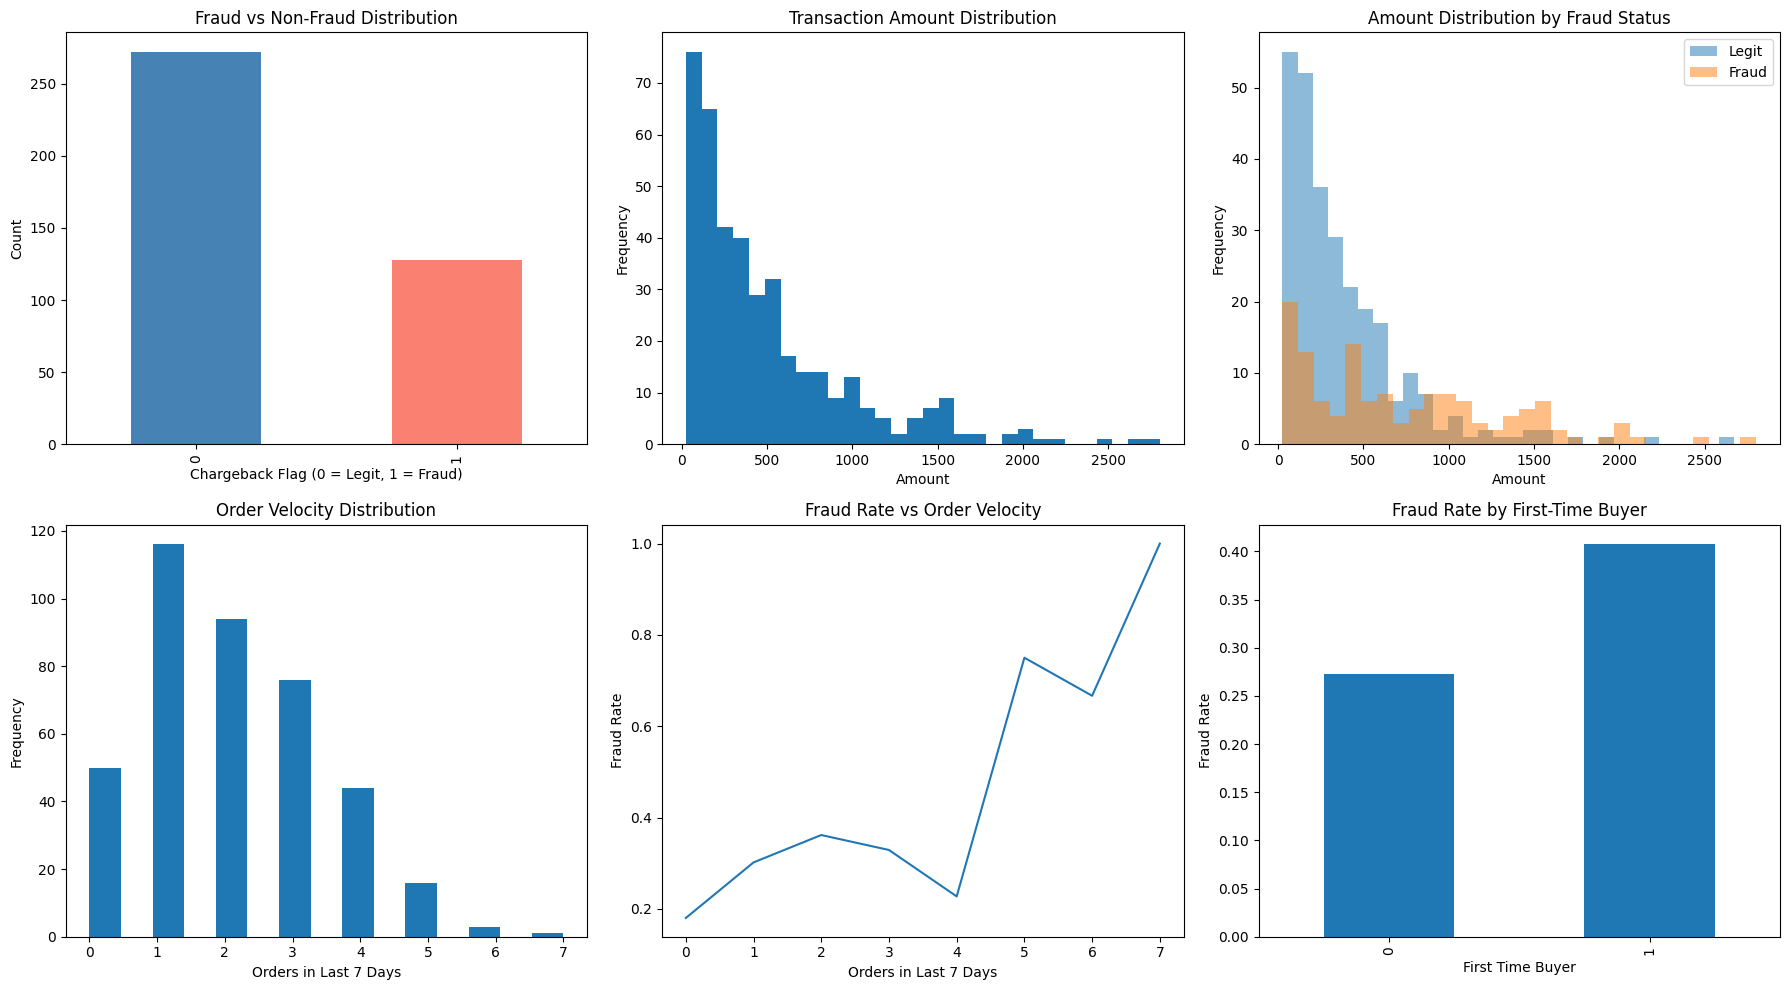

Fraud rate: 0.32


In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18,10))

# Fraud vs Non-Fraud Distribution
fraud_counts = df["chargeback_flag"].value_counts()

fraud_counts.plot(kind="bar", color=["steelblue","salmon"], ax=axes[0,0])

axes[0,0].set_title("Fraud vs Non-Fraud Distribution")
axes[0,0].set_xlabel("Chargeback Flag (0 = Legit, 1 = Fraud)")
axes[0,0].set_ylabel("Count")


# Transaction Amount Distribution
axes[0,1].hist(df["amount"], bins=30)

axes[0,1].set_title("Transaction Amount Distribution")
axes[0,1].set_xlabel("Amount")
axes[0,1].set_ylabel("Frequency")


# Amount Distribution by Fraud Status
fraud_amount = df[df["chargeback_flag"] == 1]["amount"]
nonfraud_amount = df[df["chargeback_flag"] == 0]["amount"]

axes[0,2].hist(nonfraud_amount, bins=30, alpha=0.5, label="Legit")
axes[0,2].hist(fraud_amount, bins=30, alpha=0.5, label="Fraud")

axes[0,2].set_title("Amount Distribution by Fraud Status")
axes[0,2].set_xlabel("Amount")
axes[0,2].set_ylabel("Frequency")
axes[0,2].legend()


# Order Velocity Distribution
axes[1,0].hist(df["num_orders_last_7_days"], bins=15)

axes[1,0].set_title("Order Velocity Distribution")
axes[1,0].set_xlabel("Orders in Last 7 Days")
axes[1,0].set_ylabel("Frequency")


# Fraud Rate vs Order Velocity
velocity_fraud = df.groupby("num_orders_last_7_days")["chargeback_flag"].mean()

velocity_fraud.plot(ax=axes[1,1])

axes[1,1].set_title("Fraud Rate vs Order Velocity")
axes[1,1].set_xlabel("Orders in Last 7 Days")
axes[1,1].set_ylabel("Fraud Rate")


# Fraud Rate by First-Time Buyer
first_time_fraud = df.groupby("is_first_time_buyer")["chargeback_flag"].mean()

first_time_fraud.plot(kind="bar", ax=axes[1,2])

axes[1,2].set_title("Fraud Rate by First-Time Buyer")
axes[1,2].set_xlabel("First Time Buyer")
axes[1,2].set_ylabel("Fraud Rate")


plt.tight_layout()
plt.show()


print("Fraud rate:", df["chargeback_flag"].mean())

In [11]:
df.head()

,order_id,customer_email,billing_country,shipping_country,amount,is_first_time_buyer,payment_avs_result,payment_cvv_result,num_orders_last_7_days,chargeback_flag
0,1,etnrzo@yahoo.com,AU,AU,1374.55,1,Y,Y,1,1
1,2,kajkfc@protonmail.com,US,CA,1596.60,1,Y,Y,1,1
2,3,xuiwdd@yahoo.com,CA,CA,174.90,0,Y,Y,2,0
3,4,hwmshl@gmail.com,CA,IN,440.90,0,Y,N,3,1
4,5,odxatt@yahoo.com,UK,UK,78.57,0,Y,N,2,1


#Feature Engineering and train test split

In [12]:
df_train = df.copy()
df_train["country_mismatch"] = (df_train["billing_country"] != df_train["shipping_country"]).astype(int)

df_train["payment_avs_result"] = (df_train["payment_avs_result"] == "Y").astype(int)
df_train["payment_cvv_result"] = (df_train["payment_cvv_result"] == "Y").astype(int)

df_train = df_train.drop(columns=["order_id", "customer_email", "billing_country", "shipping_country"])

In [13]:
df_train.head()

,amount,is_first_time_buyer,payment_avs_result,payment_cvv_result,num_orders_last_7_days,chargeback_flag,country_mismatch
0,1374.55,1,1,1,1,1,0
1,1596.60,1,1,1,1,1,1
2,174.90,0,1,1,2,0,0
3,440.90,0,1,0,3,1,1
4,78.57,0,1,0,2,1,0


In [14]:
X = df_train.drop("chargeback_flag", axis=1)
y = df_train["chargeback_flag"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
print("Training set fraud rate:", y_train.mean())
print("Test set fraud rate:", y_test.mean())

Training set fraud rate: 0.31875
Test set fraud rate: 0.325


#Model training and Evaluation

In [17]:
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=2, n_estimators=400, random_state=42)

In [18]:
y_prob = model.predict_proba(X_test)[:,1]
y_pred = model.predict(X_test).astype(int)
# threshold = 0.3
# y_pred = (y_prob >= threshold).astype(int)

In [19]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

[[42 12]
 [ 5 21]]
              precision    recall  f1-score   support

           0       0.89      0.78      0.83        54
           1       0.64      0.81      0.71        26

    accuracy                           0.79        80
   macro avg       0.76      0.79      0.77        80
weighted avg       0.81      0.79      0.79        80

ROC AUC: 0.7799145299145299


#Risk scoring and feature importance

In [20]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

amount                    0.518866
num_orders_last_7_days    0.162078
payment_cvv_result        0.106734
country_mismatch          0.088217
payment_avs_result        0.067939
is_first_time_buyer       0.056166
dtype: float64


Transaction amount appears as the most influential feature, followed by order velocity and address mismatch. These signals align with common fraud indicators in online transactions.

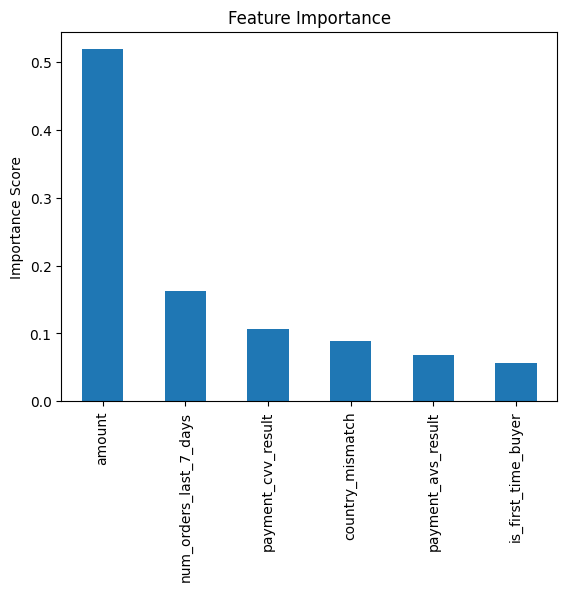

In [21]:
import matplotlib.pyplot as plt

plt.figure()
importance.plot(kind="bar")
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.show()

In [22]:
def risk_action(prob):

    if prob > 0.8:
        return "Cancel Order"

    elif prob > 0.5:
        return "Manual Verification"

    else:
        return "Approve"

In [23]:
results = X_test.copy()
results["fraud_probability"] = y_prob
results["action"] = results["fraud_probability"].apply(risk_action)

results.head()

,amount,is_first_time_buyer,payment_avs_result,payment_cvv_result,num_orders_last_7_days,country_mismatch,fraud_probability,action
264,348.38,0,1,1,4,0,0.047162,Approve
227,264.31,1,1,1,4,1,0.392676,Approve
240,310.43,0,1,0,4,1,0.655495,Manual Verification
131,950.11,1,1,1,2,0,0.878772,Cancel Order
242,665.59,0,1,1,5,1,0.603065,Manual Verification


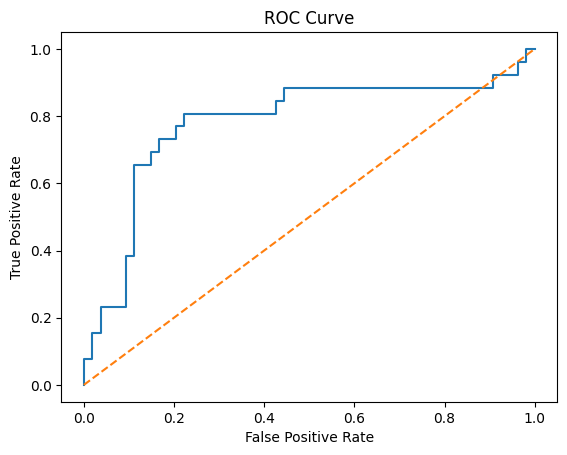

ROC-AUC: 0.7799145299145299


In [24]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

In [25]:
fraud_recall = recall_score(y_test, y_pred)
print("Fraud Recall:", fraud_recall)

Fraud Recall: 0.8076923076923077


In [31]:
import joblib

joblib.dump(model, "fraud_model.pkl")
print("Model saved")

Model saved
